### Uniform Exploration

/home/rob16817/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/rob16817/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


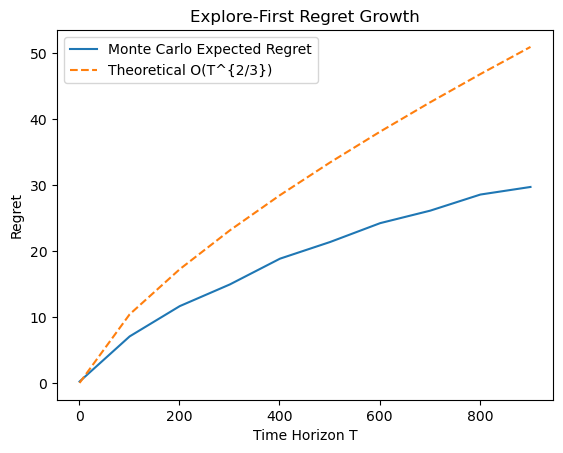

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def explore_first(mu, N, T):
    K = len(mu)
    rewards = []
    estimates = []
    for a in range(K):
        rewards_a = np.random.binomial(1, mu[a], N)
        rewards.extend(rewards_a)
        estimates.append(np.mean(rewards_a))
    #print(rewards)
    #print(estimates)
    
    best_arm = np.argmax(estimates)
    #print(best_arm)
    
    remaining = T - K * N
    if remaining > 0:
        rewards_a = np.random.binomial(1, mu[best_arm], remaining)
        rewards.extend(rewards_a)
    
    mu_star = max(mu)
    
    regret = mu_star * T - np.sum(rewards)
    return regret
    
mu = [0.4, 0.6, 0.5]
N = 20

def expected_regret(mu, T, runs=1000):
    K = len(mu)
    N = int((T/K)**(2/3) * (np.log(T))**(1/3))
    
    regrets = []
    
    for _ in range(runs):
        regrets.append(explore_first(mu, N, T))
        
    return np.mean(regrets)


time_horizons = np.arange(1, 1001, 100)
monte_carlo_expected_regret = []
C = 0.2 

for th in time_horizons:
    monte_carlo_expected_regret.append(expected_regret(mu, th))
    
theoretical_expected_regret = C * (time_horizons**(2/3))*((len(mu)*np.log(time_horizons))**(1/3))


plt.plot(time_horizons, monte_carlo_expected_regret, label="Monte Carlo Expected Regret")
plt.plot(time_horizons, theoretical_expected_regret, label="Theoretical O(T^{2/3})", linestyle="--")

plt.xlabel("Time Horizon T")
plt.ylabel("Regret")
plt.legend()
plt.title("Explore-First Regret Growth")

plt.show()

### Epsilon Greedy

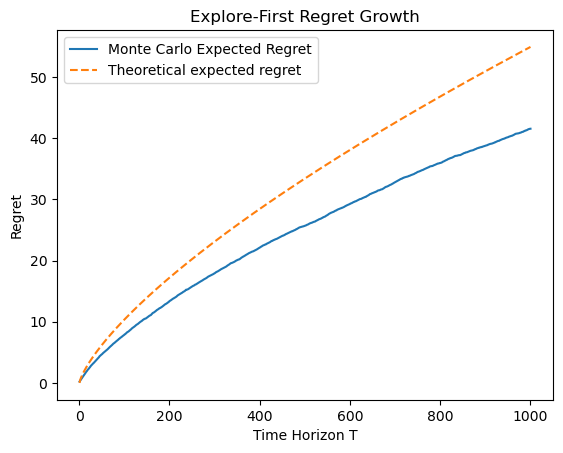

In [ ]:
def epsilon_greedy(mu, T):
    
    K = len(mu) # K is no. of arms
    estimates = np.zeros(K)
    counts = np.zeros(K)
    rewards = []
    
    for t in range(1, T + 1):  # t starts from 1 to avoid log(0)
        # epsilon_t = t^{-1/3} * (K log t)^{1/3}
        epsilon_t = (t ** (-1/3)) * ((K * np.log(t)) ** (1/3))
        
        # explore vs exploit
        if np.random.rand() < epsilon_t:
            action = np.random.randint(K)  # explore
        else:
            action = np.argmax(estimates)  # exploit
            
        reward = np.random.binomial(n=1, p=mu[action])
        
        counts[action] += 1
        
        estimates[action] += (reward - estimates[action]) / counts[action]
        
        rewards.append(reward)
    
    return rewards

def expected_regret_curve(mu, T, runs=200):
    optimal_reward = max(mu)
    cumulative_regret = np.zeros(T)
    
    for _ in range(runs):
        rewards = epsilon_greedy(mu, T)
        cumulative_regret += np.cumsum(optimal_reward - np.array(rewards))
    
    cumulative_regret /= runs  # average over runs
    return cumulative_regret

mu = [0.4, 0.6, 0.5]
N = 20
T = 1000
C = 0.2 

time_horizons = np.arange(1, T + 1)
    
expected_curve = expected_regret_curve(mu, T, runs=1000)
theoretical_expected_regret = C * (time_horizons**(2/3))*((len(mu)*np.log(time_horizons))**(1/3))


plt.plot(time_horizons, expected_curve, label="Monte Carlo Expected Regret")
plt.plot(time_horizons, theoretical_expected_regret, label="Theoretical expected regret", linestyle="--")

plt.xlabel("Time Horizon T")
plt.ylabel("Regret")
plt.legend()
plt.title("Greedy Epsilon Regret Growth")

plt.show()

### Sucessive Elimination